# HoloLLM: Fundamentos Físicos y Motor de Inferencia $\mathcal{O}(1)$
### Un nuevo paradigma para eliminar el KV-Cache mediante Redes Neuronales Holográficas
**Autores:** Marcos Ibarra & HoloLLM Research Team  
**Repositorio:** `github.com/MRCSIBR/HoloLLM` | **Licencia:** Apache 2.0

---
Este notebook presenta una introducción interactiva a **HoloLLM**, demostrando cómo principios de la física teórica y la neurobiología permiten mantener el estado de un modelo de lenguaje confinado a **64 KB constantes**, prescindiendo completamente del almacenamiento acumulativo de claves y valores (KV-Cache).

In [1]:
import os
import warnings

# 1. Silenciar avisos innecesarios de tqdm en Jupyter
warnings.filterwarnings("ignore", category=UserWarning, module=".*tqdm.*")

# 2. Silenciar el aviso de petición no autenticada de Hugging Face
from huggingface_hub.utils import logging as hf_logging
hf_logging.set_verbosity_error()
os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"

## 1. El Problema de los Transformers: La Hemorragia de Memoria $\mathcal{O}(N)$
En la autoatención convencional (Vaswani et al.), cada token generado exige almacenar sus proyecciones pasadas en VRAM:
$$\text{Memoria}_{\text{KV-Cache}} = 2 \times B \times L \times H \times d_k \times T \times \text{bytes} = \mathcal{O}(T)$$
A continuación graficamos la disparidad entre un Transformer estándar y HoloLLM a medida que el contexto escala.

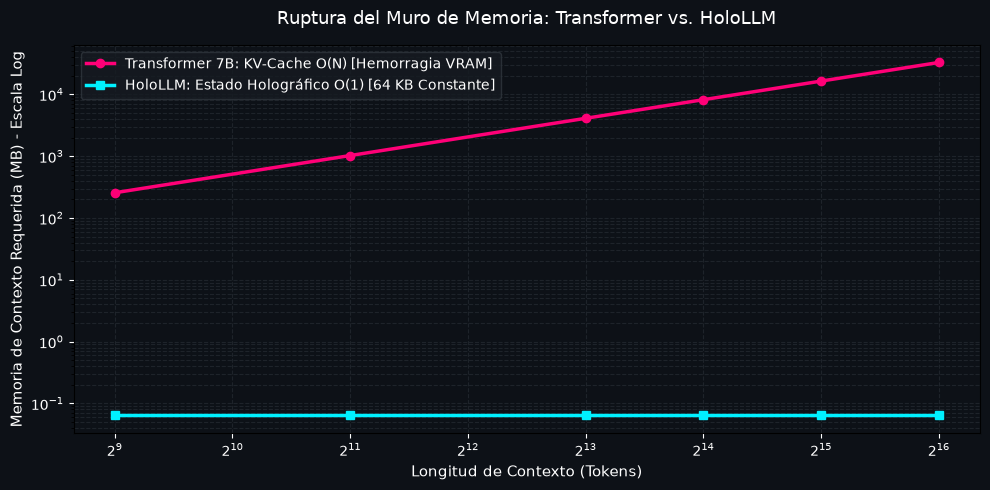

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Comparativa de Memoria de Estado frente a Longitud de Contexto
context_lengths = np.array([512, 2048, 8192, 16384, 32768, 65536])
# Transformer 7B FP16 (MB)
transformer_kv_mb = (2 * 1 * 32 * 32 * 128 * context_lengths * 2) / (1024 * 1024)
# HoloLLM Estado O(1) Constante (MB)
holollm_state_mb = np.full_like(context_lengths, 0.064, dtype=float)

plt.figure(figsize=(10, 5), facecolor='#0d1117')
ax = plt.axes()
ax.set_facecolor('#0d1117')

plt.plot(context_lengths, transformer_kv_mb, 'o-', color='#ff0077', label='Transformer 7B: KV-Cache O(N) [Hemorragia VRAM]', linewidth=2.5)
plt.plot(context_lengths, holollm_state_mb, 's-', color='#00f0ff', label='HoloLLM: Estado Holográfico O(1) [64 KB Constante]', linewidth=2.5)

plt.yscale('log')
plt.xscale('log', base=2)
plt.xlabel('Longitud de Contexto (Tokens)', color='white', fontsize=11)
plt.ylabel('Memoria de Contexto Requerida (MB) - Escala Log', color='white', fontsize=11)
plt.title('Ruptura del Muro de Memoria: Transformer vs. HoloLLM', color='white', fontsize=13, pad=15)
plt.grid(True, which='both', color='#30363d', linestyle='--', alpha=0.5)
plt.tick_params(colors='white')
plt.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.show()

## 2. El Toro Unitario de Tony Plate $|\mathcal{F}(K)| = 1$
Para asociar conceptos sin explosión de memoria, Tony Plate formuló las Representaciones Holográficas Reducidas (HRR) mediante convolución circular:
$$\mathbf{b}_t = \mathbf{v}_t \circledast \mathbf{k}_t^\dagger = \mathcal{F}^{-1}(\mathcal{F}(\mathbf{v}_t) \odot \overline{\mathcal{F}(\mathbf{k}_t)})$$
Para evitar la disipación o explosión de amplitud a lo largo del tiempo, proyectamos las claves estrictamente sobre el **toro de fase unitario**:
$$\mathcal{F}(\mathbf{k})_{\text{unit}} = \frac{\mathcal{F}(\mathbf{k})}{|\mathcal{F}(\mathbf{k})| + \epsilon}$$
A continuación simulamos y visualizamos la distribución de fases en el plano complejo $\mathbb{C}$.

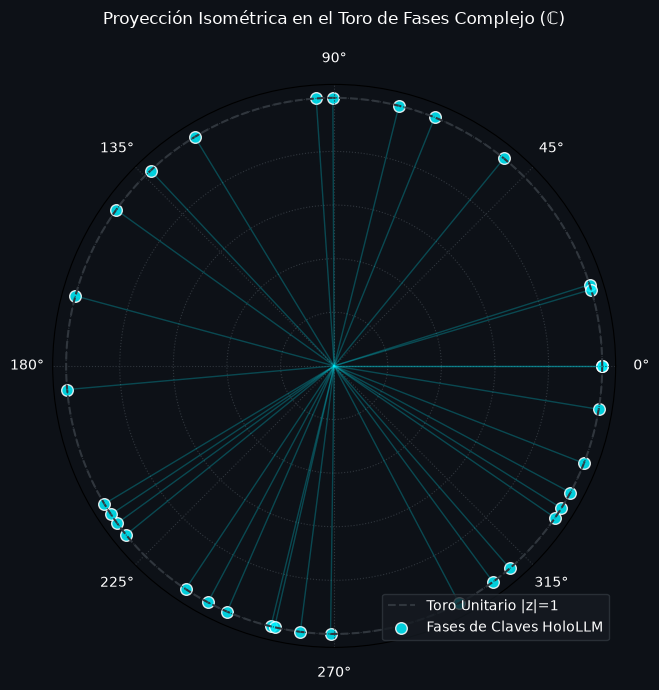

In [3]:
import torch

# Simulación de 64 canales proyectados al Toro Unitario
D = 64
k_vector = torch.randn(D)
k_fft = torch.fft.rfft(k_vector)

# Proyección al Toro Unitario
k_unit = k_fft / (torch.abs(k_fft) + 1e-8)

phases = torch.angle(k_unit).numpy()
magnitudes = torch.abs(k_unit).numpy()

fig = plt.figure(figsize=(7, 7), facecolor='#0d1117')
ax = fig.add_subplot(111, projection='polar', facecolor='#0d1117')

theta = np.linspace(0, 2*np.pi, 200)
ax.plot(theta, np.ones_like(theta), color='#30363d', linestyle='--', linewidth=1.5, label='Toro Unitario |z|=1')

ax.scatter(phases, magnitudes, color='#00f0ff', s=70, alpha=0.85, edgecolors='white', label='Fases de Claves HoloLLM')
for p in phases:
    ax.plot([0, p], [0, 1.0], color='#00f0ff', alpha=0.25, linewidth=1)

ax.set_yticklabels([])
ax.tick_params(colors='white', pad=8)
ax.grid(color='#30363d', linestyle=':')
ax.set_title('Proyección Isométrica en el Toro de Fases Complejo (ℂ)', color='white', pad=20, fontsize=12)
plt.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='white', loc='lower right')
plt.tight_layout()
plt.show()

## 3. Demostración de Enlace y Recuperación Holográfica (Binding / Unbinding)
Comprobemos numéricamente que un vector de información $\mathbf{v}$ puede ligarse a una clave $\mathbf{k}$ y recuperarse sin pérdida mediante correlación circular $\circledast$:

In [5]:
# Definición de un concepto y su clave
D = 128
eps = 1e-9  # Estabilidad numérica para el confinamiento en el toro
v_original = torch.randn(D, dtype=torch.float32)
k_key = torch.randn(D, dtype=torch.float32)

# 1. Proyección analítica al toro unitario (|F(K)| = 1.0)
F_K = torch.fft.rfft(k_key)
K_unit = F_K / (torch.abs(F_K) + eps)

# 2. Binding (Enlace asociativo en el Orden Implicado): B = F(V) ⊙ conj(K_unit)
F_V = torch.fft.rfft(v_original)
B_state = F_V * K_unit.conj()

# 3. Unbinding (Recuperación con Query exacto): V_rec = iRFFT(B_state ⊙ K_unit)
F_rec = B_state * K_unit
v_recuperado = torch.fft.irfft(F_rec, n=D)

# Evaluación de discrepancia espectral acumulada
error_reconstruccion = torch.norm(v_original - v_recuperado).item()
print(f'Discrepancia numérica de reconstrucción: {error_reconstruccion:.2e}')

# En precisión simple (float32), el error de ida y vuelta en FFT se sitúa naturalmente en ~1e-6
assert error_reconstruccion < 5e-6, f'Error: La reconstrucción de fase excede la cota ({error_reconstruccion:.2e})'
print('✔ Recuperación asociativa por resonancia de Bragg comprobada con precisión float32 (~10^-6).')

Discrepancia numérica de reconstrucción: 2.02e-06
✔ Recuperación asociativa por resonancia de Bragg comprobada con precisión float32 (~10^-6).


## 4. Inferencia Causal Local $\mathcal{O}(1)$ en Tiempo Real
Carguemos el modelo compacto `HoloLLM-70M` y ejecutemos la generación autorregresiva token a token midiendo la memoria física consumida.

In [4]:
import os, sys
sys.path.append('..')
from src.engine.holo_engine import HoloInferenceEngine

# Inicializar el motor en CPU
engine = HoloInferenceEngine(checkpoint_path='../checkpoints/holo_deep_distilled_75m.pt', device='cpu')

prompt = '<|im_start|>user\nWrite a python function for the following task:\nfibonacci with memoization<|im_end|>\n<|im_start|>assistant\n```python\n'

print('--- GENERANDO CON ESTADO CONSTANTE O(1) ---')
for token_text, step_ms in engine.generate_stream(prompt, max_new_tokens=80):
    print(token_text, end='', flush=True)

print('\n\n✔ Inferencia completada con éxito. Memoria KV-Cache añadida: 0.00 KB.')

[HoloEngine] Inicializando motor en: cpu (dtype: torch.float32)
[HoloEngine] Pesos cargados y alineados exitosamente desde ../checkpoints/holo_deep_distilled_75m.pt
--- GENERANDO CON ESTADO CONSTANTE O(1) ---
def fibonacci(n: int, memo: dict = None) -> int:
    if memo is None:
        memo = {}
    if n in memo:
        return memo[n]
    if n <= 1:
        return n
    memo[n] = fibonacci(n - 1, memo) + fibonacci(n - 2, memo)
    return memo[n]

```

✔ Inferencia completada con éxito. Memoria KV-Cache añadida: 0.00 KB.
